[0.65, 1.3, 2.0, 2.75, 3.5500000000000003, 4.45, 5.4, 6.45, 7.65, 9.0, 10.55, 12.4, 14.65, 17.45, 20.950000000000003, 25.1, 29.5, 34.0, 38.5, 43.0, 47.5, 52.0, 56.5, 61.0, 65.5, 70.0, 74.5, 79.0, 83.5, 88.0, 92.5, 97.0]
[0.65 0.7  0.75 0.8  0.9  0.95 1.05 1.2  1.35 1.55 1.85 2.25 2.8  3.5
 4.15 4.4  4.5  4.5  4.5  4.5  4.5  4.5  4.5  4.5  4.5  4.5  4.5  4.5
 4.5  4.5  4.5 ]


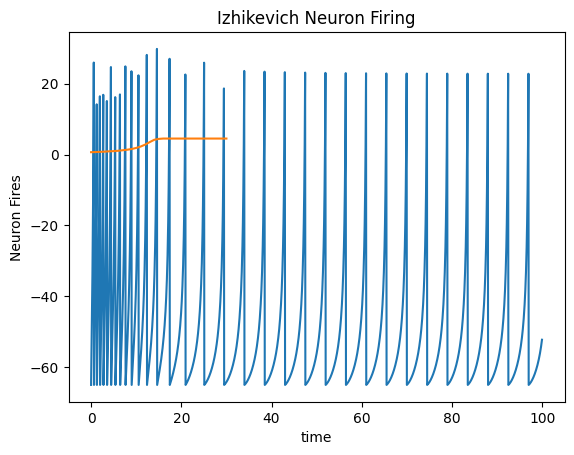

In [22]:
#Izhikevich Model 
#v is membrane potential variable
#u is recovery  variable

import numpy as np
import matplotlib.pyplot as plt

def ODE(a,b,c,d,I,u,v,T):
    vaxis = []
    uaxis = []
    spike_times = []
    dt = 0.05
    n_steps = int(T / dt)
    for i in range(n_steps):
        vaxis.append(v)
        uaxis.append(u)
        dv = 0.04*v**2 + 5*v + 140 - u + I
        du = a * (b*v - u)
        v = v + dv * dt
        u = u + du * dt 
        if v >= 30: 
            v = c
            u = u + d
            spike_times.append((i + 1) * dt)
    return uaxis, vaxis, spike_times
dt = 0.05


uaxis,vaxis,spike_times= ODE(0.02,0.2,-65,8,100,-13,-65,100)
print(spike_times)
ISI = np.diff(spike_times)
print(ISI)
time = np.arange(len(uaxis)) * dt
plt.plot(time, vaxis)
plt.plot(ISI)
plt.xlabel("time")
plt.ylabel("Neuron Fires")
plt.title("Izhikevich Neuron Firing")
plt.show()

In [16]:
steady_ISI = np.mean(ISI[-5:])
frequency = 1000 / steady_ISI

print(steady_ISI)
print(frequency)

4.5
222.22222222222223


[0, np.float64(43.47826086956522), np.float64(86.58008658008657), np.float64(131.23359580052485), np.float64(176.99115044247787), np.float64(222.22222222222223)]


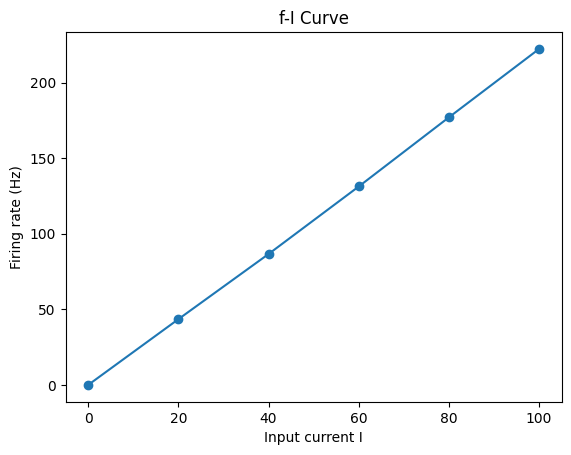

In [18]:
I_values = np.arange(0,101,20)
frequencies = []

for I in I_values:
    spike_times = ODE(0.02,0.2,-65,8,I,-13,-65,1000)[2]
    if len(spike_times) >= 6: 
        ISI = np.diff(spike_times)
        steady_ISI = np.mean(ISI[-5:])
        frequency = 1000 / steady_ISI 
        frequencies.append(frequency)
    else:
        #just to remember I set f = 0 once we have less than 6 spikes, because I take mean of last five so the length should be more than 5 at least. 
        frequency = 0
        frequencies.append(frequency)

print(frequencies)

#frequency-current plot(f-I plot)
plt.plot(I_values, frequencies, marker="o")
plt.xlabel("Input current I")
plt.ylabel("Firing rate (Hz)")
plt.title("f-I Curve")
plt.show()


[np.float64(222.22222222222223), np.float64(222.22222222222223), np.float64(222.22222222222223), np.float64(222.22222222222223), np.float64(222.22222222222223), np.float64(222.22222222222223), np.float64(222.22222222222223), np.float64(222.22222222222223), np.float64(222.22222222222223), np.float64(222.22222222222223), np.float64(222.22222222222223), np.float64(222.22222222222223), np.float64(222.22222222222223), np.float64(222.22222222222223), np.float64(222.22222222222223), np.float64(222.22222222222223), np.float64(222.22222222222223), np.float64(222.22222222222223), np.float64(222.22222222222223), np.float64(222.22222222222223), np.float64(222.22222222222223)]


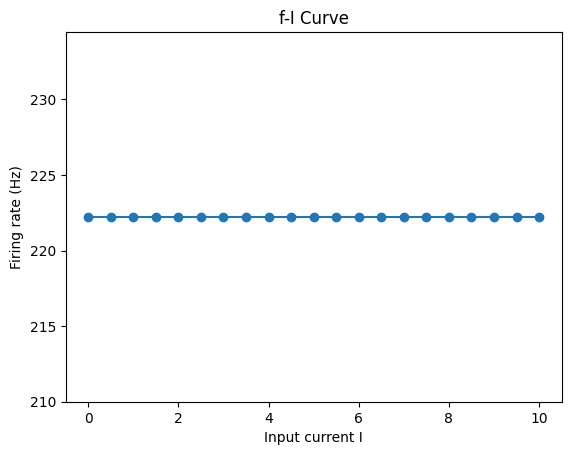

In [19]:
I_values = np.arange(0,10.5,0.5)
frequencies = []

for I in I_values:
    spike_times = ODE(0.02,0.2,-65,8,100,-13,-65,1000)[2]
    if len(spike_times) >= 6: 
        ISI = np.diff(spike_times)
        steady_ISI = np.mean(ISI[-5:])
        frequency = 1000 / steady_ISI 
        frequencies.append(frequency)
    else:
        #just to remember I set f = 0 once we have less than 6 spikes, because I take mean of last five so the length should be more than 5 at least. 
        frequency = 0
        frequencies.append(frequency)

print(frequencies)

#frequency-current plot(f-I plot)
plt.plot(I_values, frequencies, marker="o")
plt.xlabel("Input current I")
plt.ylabel("Firing rate (Hz)")
plt.title("f-I Curve")
plt.show()

In [23]:
for I in [3.5, 4.0, 4.5]:
    _, _, spike_times = ODE(0.02,0.2,-65,8,I,-13,-65,1000)
    print(I,len(spike_times))

3.5 1
4.0 8
4.5 10


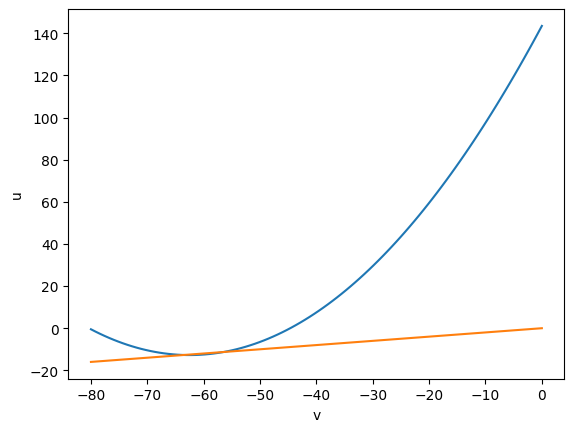

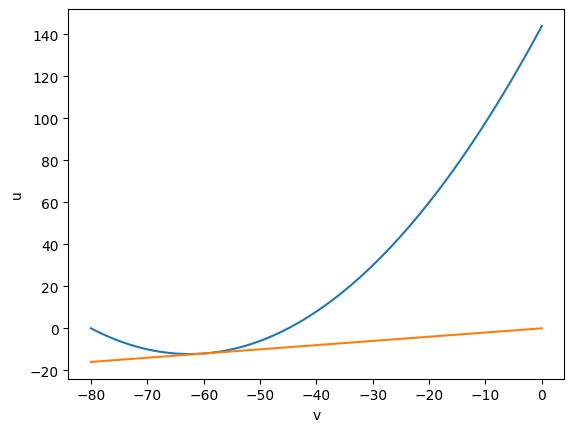

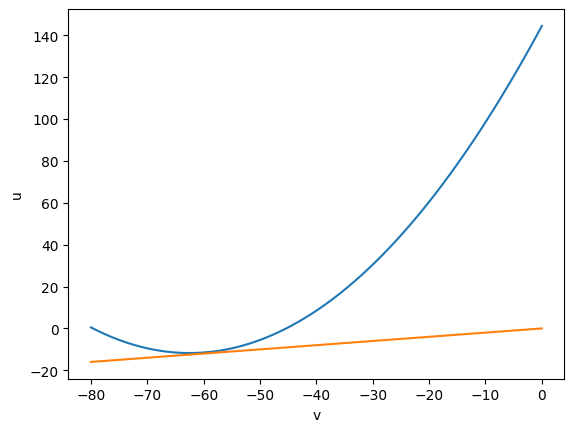

In [28]:
v = np.linspace(-80, 0, 100)
for I in [3.5, 4.0, 4.5]: 
    u_v = 0.04*v**2 + 5*v + 140 + I
    u_u = 0.2*v
    plt.plot(v, u_v)
    plt.plot(v, u_u)
    plt.xlabel("v")
    plt.ylabel("u")
    plt.show()

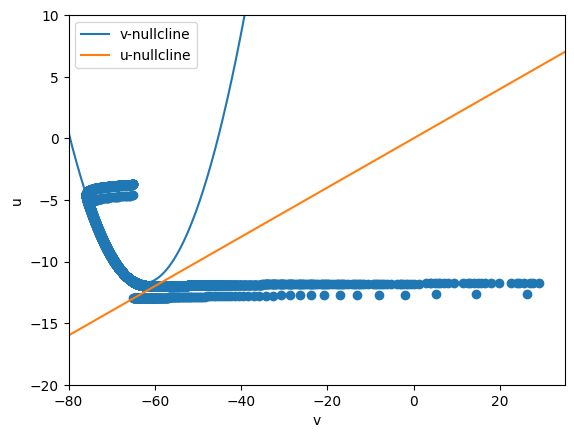

In [30]:
I = 4.5

uaxis, vaxis, spike_times = ODE(
    0.02, 0.2, -65, 8, I, -13, -65, 1000
)

v = np.linspace(-80, 35, 1000)

v_nullcline = 0.04*v**2 + 5*v + 140 + I
u_nullcline = 0.2*v

plt.plot(v, v_nullcline, label="v-nullcline")
plt.plot(v, u_nullcline, label="u-nullcline")

plt.scatter(vaxis, uaxis, linewidth=1)

plt.xlabel("v")
plt.ylabel("u")
plt.legend()
plt.xlim(-80, 35)
plt.ylim(-20, 10)
plt.show()